<a href="https://colab.research.google.com/github/DienAkbar25/DesainAnalisisAlgoritma/blob/Lolo/DAA(TRIP_PLANNER).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx

import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import time

In [ ]:
places = {
    1: "Malioboro",
    2: "Tugu Jogja",
    3: "Alun-Alun Kidul",
    4: "Keraton Yogyakarta",
    5: "Taman Sari",
    6: "Museum Sonobudoyo",
    7: "Candi Prambanan",
    8: "Ratu Boko",
    9: "Tebing Breksi",
    10: "Kaliurang",
    11: "Basecamp Lava Tour Merapi",
    12: "Museum Ullen Sentalu",
    13: "Pantai Parang Teritis",
    14: "HeHa Sky View",
    15: "Hutam Pinus Pengger"
}

In [ ]:
day = {
    1: 1, 2: 1, 3: 1,
    4: 2, 5: 2, 6: 2,
    7: 3, 8: 3, 9: 3,
    10: 4, 11: 4, 12: 4,
    13: 5, 14: 5, 15: 5
}

In [ ]:
graph = {
    1: [(4, 2), (5, 3)],
    2: [(4, 2)],
    3: [(5, 2), (6, 3)],

    4: [(7, 16), (8, 17)],
    5: [(8, 18)],
    6: [(9, 14)],

    7: [(10, 24), (11, 23)],
    8: [(11, 22)],
    9: [(12, 20)],

    10: [(14, 18)],
    11: [(13, 28)],
    12: [(15, 26)],

    13: [],
    14: [],
    15: []
}


In [ ]:
def compute_indegree(graph, N):
    indeg = {i: 0 for i in range(1, N+1)}
    for u, edges in graph.items():
        for v, w in edges:
            indeg[v] += 1
    return indeg

def print_order(order, title):
    print(title)
    for node in order:
        print(f"{node:2d} - {places[node]} (Hari {day[node]})")
    print()


In [ ]:
def topo_kahn(graph, N):
    indeg = compute_indegree(graph, N)
    q = deque()

    # masukin semua node dengan in-degree 0 ke queue
    for node in range(1, N+1):
        if indeg[node] == 0:
            q.append(node)

    order = []
    while q:
        u = q.popleft()
        order.append(u)
        for v, w in graph.get(u, []):
            indeg[v] -= 1
            if indeg[v] == 0:
                q.append(v)

    if len(order) != N:
        print(" DAG tidak valid / ada cycle.")
        return None
    return order


In [ ]:
def topo_dfs(graph, N):
    visited = {i: False for i in range(1, N+1)}
    stack = []

    def dfs(u):
        visited[u] = True
        for v, w in graph.get(u, []):
            if not visited[v]:
                dfs(v)
        stack.append(u)  # catat saat PULANG

    for node in range(1, N+1):
        if not visited[node]:
            dfs(node)

    stack.reverse()  # dibalik jadi topo order
    return stack


In [ ]:
def build_weight_lookup(graph):
    # biar gampang cek bobot u->v
    w = {}
    for u, edges in graph.items():
        for v, weight in edges:
            w[(u, v)] = weight
    return w

weight_lookup = build_weight_lookup(graph)

def total_distance(order, weight_lookup):
    dist = 0
    for i in range(len(order)-1):
        u = order[i]
        v = order[i+1]
        if (u, v) in weight_lookup:
            dist += weight_lookup[(u, v)]
        # else: bisa skip / asumsi pindah bebas, ini dummy saja
    return dist

def stability(order1, order2):
    pos1 = {node: i for i, node in enumerate(order1)}
    pos2 = {node: i for i, node in enumerate(order2)}
    diff = 0
    for node in pos1:
        if pos1[node] != pos2[node]:
            diff += 1
    return 1 - diff / len(order1)  # skala 0..1

def run_with_time(func, *args):
    t0 = time.perf_counter()
    result = func(*args)
    t1 = time.perf_counter()
    return result, (t1 - t0) * 1000.0  # ms


In [ ]:
G = nx.DiGraph()

# Tambah node
for node in places.keys():
    G.add_node(node, label=places[node], day=day[node])

# Tambah edge + bobot
for u, edges in graph.items():
    for v, w in edges:
        G.add_edge(u, v, weight=w)


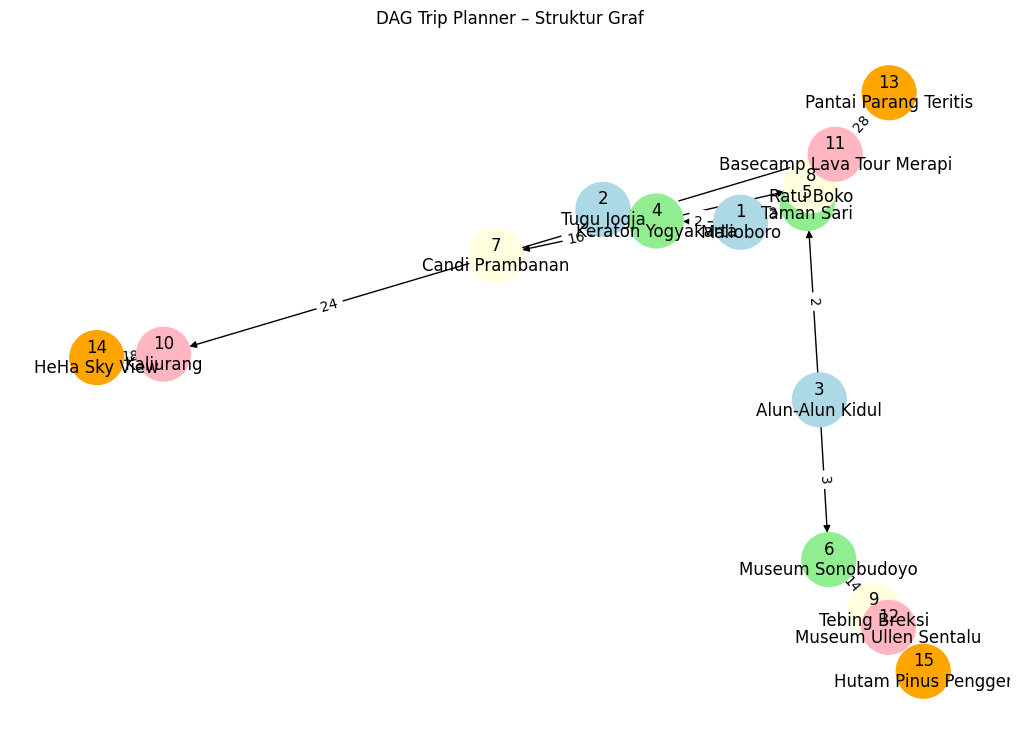

In [ ]:
def get_node_colors_by_day():
    colors = []
    for n in G.nodes():
        d = day[n]
        if d == 1: colors.append("lightblue")
        elif d == 2: colors.append("lightgreen")
        elif d == 3: colors.append("lightyellow")
        elif d == 4: colors.append("lightpink")
        else: colors.append("orange")
    return colors

def draw_base_graph(G):
    plt.figure(figsize=(10, 7))
    pos = nx.spring_layout(G, seed=42)

    labels = {n: f"{n}\n{places[n]}" for n in G.nodes()}
    node_colors = get_node_colors_by_day()

    nx.draw(
        G, pos,
        with_labels=True,
        labels=labels,
        node_size=1500,
        node_color=node_colors,
        arrows=True
    )

    edge_labels = {(u, v): G[u][v]['weight'] for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title("DAG Trip Planner – Struktur Graf")
    plt.axis("off")
    plt.show()
    return pos

pos = draw_base_graph(G)


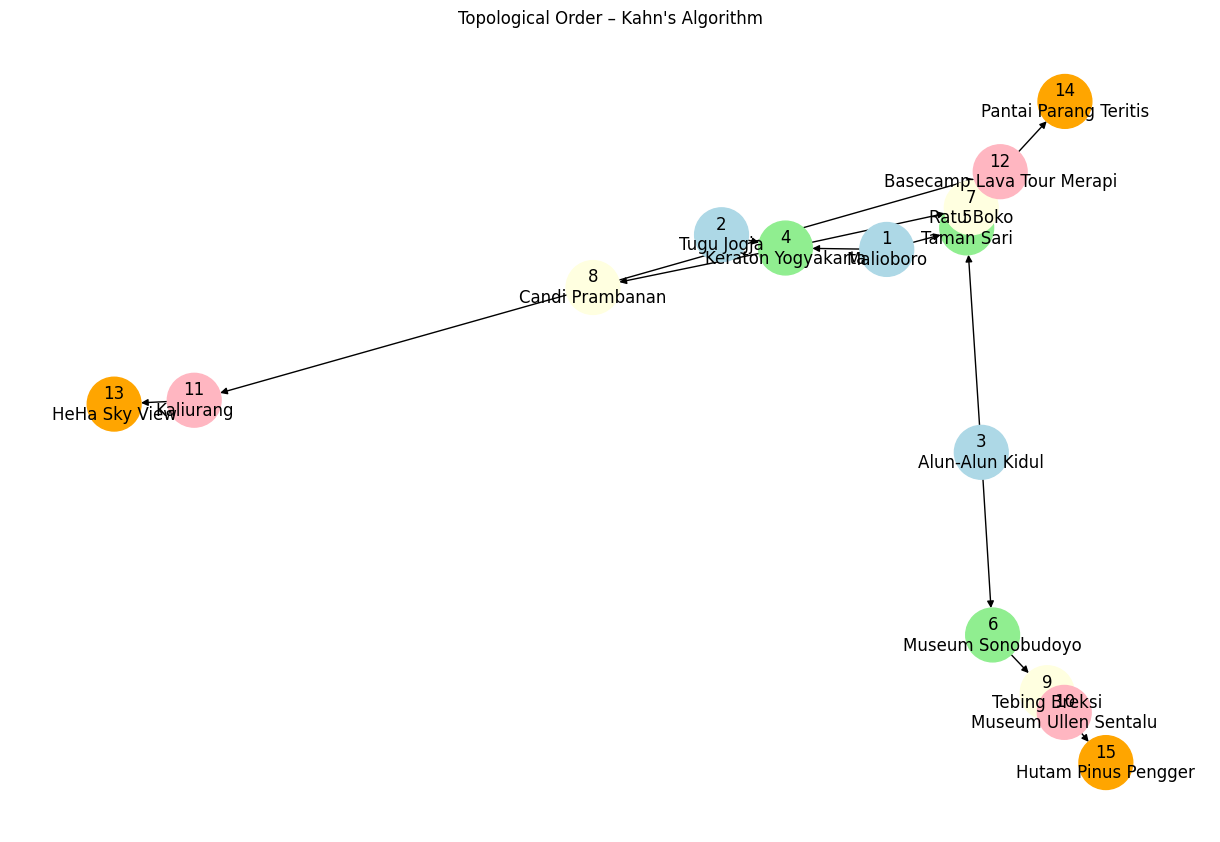

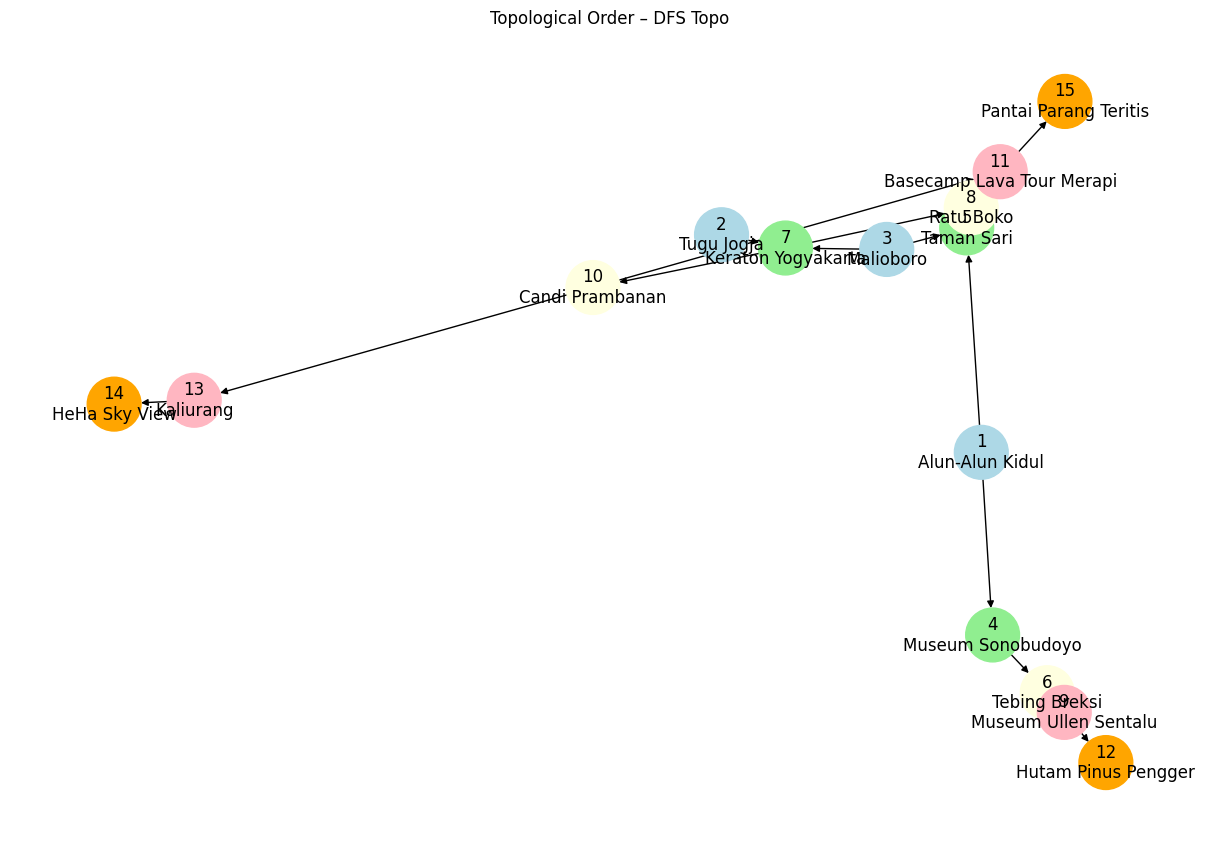

In [ ]:
def draw_topo_order(G, order, pos, title):
    plt.figure(figsize=(12, 8))

    rank = {node: i+1 for i, node in enumerate(order)}
    labels = {n: f"{rank[n]}\n{places[n]}" for n in G.nodes()}
    node_colors = get_node_colors_by_day()

    nx.draw(
        G, pos,
        with_labels=True,
        labels=labels,
        node_size=1500,
        node_color=node_colors,
        arrows=True
    )

    plt.title(title)
    plt.axis("off")
    plt.show()

# Pastikan order_kahn & order_dfs sudah dihitung di Step 6
draw_topo_order(G, order_kahn, pos, "Topological Order – Kahn's Algorithm")
draw_topo_order(G, order_dfs, pos, "Topological Order – DFS Topo")


In [ ]:
# Kahn
order_kahn, time_kahn = run_with_time(topo_kahn, graph, N)
print_order(order_kahn, "=== TOPOLOGICAL ORDER - KAHN ===")
print(f"Runtime Kahn : {time_kahn:.4f} ms")
dist_kahn = total_distance(order_kahn, weight_lookup)
print(f"Total jarak (approx) Kahn : {dist_kahn} km\n")

# DFS
order_dfs, time_dfs = run_with_time(topo_dfs, graph, N)
print_order(order_dfs, "=== TOPOLOGICAL ORDER - DFS ===")
print(f"Runtime DFS  : {time_dfs:.4f} ms")
dist_dfs = total_distance(order_dfs, weight_lookup)
print(f"Total jarak (approx) DFS  : {dist_dfs} km\n")

# Bandingkan stabilitas
stab = stability(order_kahn, order_dfs)
print("=== PERBANDINGAN ===")
print(f"Stabilitas urutan (Kahn vs DFS): {stab:.2f} (0 = beda banget, 1 = sama)")


=== TOPOLOGICAL ORDER - KAHN ===
 1 - Malioboro (Hari 1)
 2 - Tugu Jogja (Hari 1)
 3 - Alun-Alun Kidul (Hari 1)
 4 - Keraton Yogyakarta (Hari 2)
 5 - Taman Sari (Hari 2)
 6 - Museum Sonobudoyo (Hari 2)
 7 - Candi Prambanan (Hari 3)
 8 - Ratu Boko (Hari 3)
 9 - Tebing Breksi (Hari 3)
10 - Kaliurang (Hari 4)
11 - Basecamp Lava Tour Merapi (Hari 4)
12 - Museum Ullen Sentalu (Hari 4)
14 - HeHa Sky View (Hari 5)
13 - Pantai Parang Teritis (Hari 5)
15 - Hutam Pinus Pengger (Hari 5)

Runtime Kahn : 0.0308 ms
Total jarak (approx) Kahn : 0 km

=== TOPOLOGICAL ORDER - DFS ===
 3 - Alun-Alun Kidul (Hari 1)
 6 - Museum Sonobudoyo (Hari 2)
 9 - Tebing Breksi (Hari 3)
12 - Museum Ullen Sentalu (Hari 4)
15 - Hutam Pinus Pengger (Hari 5)
 2 - Tugu Jogja (Hari 1)
 1 - Malioboro (Hari 1)
 5 - Taman Sari (Hari 2)
 4 - Keraton Yogyakarta (Hari 2)
 8 - Ratu Boko (Hari 3)
 7 - Candi Prambanan (Hari 3)
11 - Basecamp Lava Tour Merapi (Hari 4)
13 - Pantai Parang Teritis (Hari 5)
10 - Kaliurang (Hari 4)
14 - He